In [2]:
# ============================================
# CELL 0 — LOAD DATA + CONFIGURATION + IMPORTS
# ============================================

# --- FILE PATHS (edit these as needed) ---
# You can change to .parquet, .feather, etc. if that's your format.
TRANSACTIONS_PATH = "transactions_train.csv"   # or "data/transactions.parquet"
ARTICLES_PATH     = "articles.csv"       # optional, used for category info

# --- CONFIGURATION ---
ID_CUSTOMER = "customer_id"      # unique customer identifier
ID_ITEM = "article_id"           # unique item/article identifier
DT_COL = "t_dat"                 # transaction datetime column
PRICE_COL = "price"              # numeric price column
CAT_COL = "garment_group_name"   # optional category column in `articles`, set None if unused

# Feature placeholders (filled later once engineered)
numerical_features = []
categorical_features = []
binary_features = []

# Reproducibility
RANDOM_STATE = 42

# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.utils import check_random_state

# Pandas display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# ============================================
# LOAD DATA
# ============================================
# Read transactions
if TRANSACTIONS_PATH.endswith(".csv"):
    transactions = pd.read_csv(TRANSACTIONS_PATH)
elif TRANSACTIONS_PATH.endswith(".parquet"):
    transactions = pd.read_parquet(TRANSACTIONS_PATH)
else:
    raise ValueError("Unsupported format for TRANSACTIONS_PATH")

# Read articles if available
try:
    if CAT_COL is not None:
        if ARTICLES_PATH.endswith(".csv"):
            articles = pd.read_csv(ARTICLES_PATH)
        elif ARTICLES_PATH.endswith(".parquet"):
            articles = pd.read_parquet(ARTICLES_PATH)
        else:
            raise ValueError("Unsupported format for ARTICLES_PATH")
    else:
        articles = pd.DataFrame()
except FileNotFoundError:
    print("⚠️ Warning: articles file not found; category-based features will be skipped.")
    articles = pd.DataFrame()

# ============================================
# BASIC SANITY CHECKS
# ============================================
required_tx_cols = [ID_CUSTOMER, ID_ITEM, DT_COL, PRICE_COL]
missing_tx = [c for c in required_tx_cols if c not in transactions.columns]
if missing_tx:
    raise ValueError(f"Missing columns in `transactions`: {missing_tx}")

# Ensure datetime type
transactions[DT_COL] = pd.to_datetime(transactions[DT_COL], errors="coerce")
if transactions[DT_COL].isna().any():
    raise ValueError(f"Some rows in `transactions[{DT_COL}]` could not be converted to datetime.")

# Validate article metadata
if CAT_COL is not None and not articles.empty:
    if CAT_COL not in articles.columns:
        raise ValueError(f"Column `{CAT_COL}` not found in `articles` DataFrame.")
elif CAT_COL is not None and articles.empty:
    print("⚠️ No `articles` data loaded; category-based features will be skipped.")
    CAT_COL = None

# ============================================
# SUMMARY
# ============================================
print("✅ Data successfully loaded and validated.")
print(f"Transactions: {len(transactions):,} rows | Columns: {transactions.columns.tolist()}")
if CAT_COL is not None:
    print(f"Articles: {len(articles):,} rows | Category column: {CAT_COL}")
print(f"Random state: {RANDOM_STATE}")
print("Ready to proceed with feature engineering.")


✅ Data successfully loaded and validated.
Transactions: 31,788,324 rows | Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']
Articles: 105,542 rows | Category column: garment_group_name
Random state: 42
Ready to proceed with feature engineering.


In [3]:
# Define a 7-day target window at the end of the timeline
max_date = transactions[DT_COL].max()
cutoff_date = max_date - pd.Timedelta(days=7)

hist = transactions[transactions[DT_COL] < cutoff_date].copy()   # used ONLY for feature engineering
target = transactions[transactions[DT_COL] >= cutoff_date].copy()  # used for labels/candidates

print(f"Max date: {max_date.date()} | Cutoff: {cutoff_date.date()}")
print(f"hist rows: {len(hist):,} | target rows: {len(target):,}")


Max date: 2020-09-22 | Cutoff: 2020-09-15
hist rows: 31,521,960 | target rows: 266,364


In [4]:
# User-level average price (past only)
user_avg_price = (
    hist.groupby(ID_CUSTOMER, as_index=False)[PRICE_COL]
        .mean()
        .rename(columns={PRICE_COL: "user_avg_price"})
        .astype({"user_avg_price": "float32"})
)

# Item-level average price (past only)
item_avg_price = (
    hist.groupby(ID_ITEM, as_index=False)[PRICE_COL]
        .mean()
        .rename(columns={PRICE_COL: "item_avg_price"})
        .astype({"item_avg_price": "float32"})
)

# User last purchase date / recency relative to cutoff (past only)
user_last_purchase = (
    hist.groupby(ID_CUSTOMER, as_index=False)[DT_COL]
        .max()
        .rename(columns={DT_COL: "last_purchase_date"})
)
user_last_purchase["recency_days"] = (cutoff_date - user_last_purchase["last_purchase_date"]).dt.days
user_last_purchase["recency_days"] = user_last_purchase["recency_days"].fillna(user_last_purchase["recency_days"].max() + 1).astype("int32")

# Optional: category history "has bought before" (built from hist ONLY)
if CAT_COL is not None:
    # Join hist with article categories
    hist_cat = hist[[ID_CUSTOMER, ID_ITEM]].merge(
        articles[[ID_ITEM, CAT_COL]], on=ID_ITEM, how="left"
    )
    # Deduplicate prior categories per customer
    user_category_history = (
        hist_cat[[ID_CUSTOMER, CAT_COL]].dropna().drop_duplicates()
    )
else:
    user_category_history = None


In [5]:
# POSITIVES: customer, article pairs in the target window
positives = (
    target[[ID_CUSTOMER, ID_ITEM]]
    .drop_duplicates()
    .assign(label=1)
)

# --- NEGATIVE SAMPLING (simple uniform) ---
# For each customer in target, sample items they did NOT buy in target
rng = check_random_state(RANDOM_STATE)

unique_customers = positives[ID_CUSTOMER].unique()
unique_items = transactions[ID_ITEM].unique()

# Map of customer -> set of positive items (in target)
pos_map = (
    positives.groupby(ID_CUSTOMER)[ID_ITEM]
    .apply(set)
    .to_dict()
)

neg_rows = []
# You can adjust negatives_per_pos (e.g., 1-5)
negatives_per_pos = 1

for cust in unique_customers:
    pos_items = pos_map.get(cust, set())
    n_pos = len(pos_items)
    n_neg = n_pos * negatives_per_pos
    # Sample without replacement from all items minus positives
    # (If catalog is huge, consider sampling from a candidate shortlist instead)
    candidate_pool = np.setdiff1d(unique_items, np.array(list(pos_items)))
    if len(candidate_pool) == 0 or n_neg == 0:
        continue
    sampled = rng.choice(candidate_pool, size=min(n_neg, len(candidate_pool)), replace=False)
    neg_rows.extend([(cust, it, 0) for it in sampled])

negatives = pd.DataFrame(neg_rows, columns=[ID_CUSTOMER, ID_ITEM, "label"])

training_pairs = pd.concat([positives, negatives], ignore_index=True)

print(f"Positives: {len(positives):,} | Negatives: {len(negatives):,} | Total: {len(training_pairs):,}")


Positives: 236,622 | Negatives: 236,622 | Total: 473,244


In [6]:
# ============================================
# CELL 4 — JOIN ENGINEERED FEATURES (PAST-ONLY) TO TRAINING PAIRS
# ============================================

# Join item & user features
training_data = (
    training_pairs
    .merge(user_avg_price, on=ID_CUSTOMER, how="left")
    .merge(item_avg_price, on=ID_ITEM, how="left")
    .merge(user_last_purchase[[ID_CUSTOMER, "recency_days"]], on=ID_CUSTOMER, how="left")
)

# Optional: add category-based "has_bought_before" (from hist only)
if CAT_COL is not None:
    # Attach the candidate's category (current item's category)
    training_data = training_data.merge(articles[[ID_ITEM, CAT_COL]], on=ID_ITEM, how="left")

    # Flag if the user has seen this category in the past (strictly before cutoff)
    if user_category_history is not None:
        training_data["has_bought_category_before"] = (
            training_data[[ID_CUSTOMER, CAT_COL]]
            .merge(
                user_category_history.assign(has_bought_category_before=1),
                on=[ID_CUSTOMER, CAT_COL],
                how="left"
            )["has_bought_category_before"]
            .fillna(0)
            .astype("int8")
        )
    else:
        training_data["has_bought_category_before"] = 0

# Fill missing engineered numeric features
for col in ["user_avg_price", "item_avg_price", "recency_days"]:
    if col in training_data.columns:
        training_data[col] = training_data[col].fillna(training_data[col].median())

# --------------------------------------------
# Define your feature lists cleanly (no undefined variables)
# --------------------------------------------

# Start with the engineered numerical features
numerical_features = [c for c in ["user_avg_price", "item_avg_price", "recency_days"] if c in training_data.columns]

# Add any other numeric columns already present in your dataset
extra_numeric_features = [
    c for c in training_data.select_dtypes(include=["number"]).columns
    if c not in numerical_features + ["label"]
]
numerical_features += extra_numeric_features

# Collect categorical and binary features if they exist
if CAT_COL is not None and CAT_COL in training_data.columns:
    categorical_features = list(set(categorical_features + [CAT_COL]))
else:
    categorical_features = categorical_features or []

binary_features = [c for c in binary_features if c in training_data.columns]

# Final feature list
features = numerical_features + categorical_features + binary_features

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)
print("Total features:", len(features))


Numerical features: ['user_avg_price', 'item_avg_price', 'recency_days', 'article_id', 'has_bought_category_before']
Categorical features: ['garment_group_name']
Binary features: []
Total features: 6


In [7]:
y = training_data["label"].astype(int).values
groups = training_data[ID_CUSTOMER].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(training_data, y, groups=groups))

train_df = training_data.iloc[train_idx].reset_index(drop=True)
val_df   = training_data.iloc[val_idx].reset_index(drop=True)

X_train = train_df[features].copy()
X_val   = val_df[features].copy()
y_train = train_df["label"].values
y_val   = val_df["label"].values

print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")


Train: 378,554 | Val: 94,690


In [9]:
# ============================================
# PREPROCESSING + MODEL (version-safe for sklearn)
# ============================================
from sklearn import __version__ as skver
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Make sure IDs aren’t in the features
id_like_cols = {ID_CUSTOMER, ID_ITEM}
numerical_features = [c for c in numerical_features if c not in id_like_cols]
categorical_features = [c for c in categorical_features if c not in id_like_cols]

# Build numeric pipeline
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Build categorical pipeline with correct OneHotEncoder arg by sklearn version
def make_ohe():
    # Parse major.minor
    major_minor = tuple(int(x) for x in skver.split(".")[:2])
    if major_minor >= (1, 2):
        # New API: 'sparse_output' (and 'sparse' removed in 1.4+)
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    else:
        # Old API: 'sparse'
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

cat_transformer = Pipeline(steps=[
    ("ohe", make_ohe())
]) if len(categorical_features) else "drop"

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_features),
        ("cat", cat_transformer, categorical_features)
    ],
    remainder="drop"
)

# Simple baseline model (compatible across versions)
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Train AUC: 0.6886
Val   AUC: 0.6878


<Figure size 500x400 with 0 Axes>

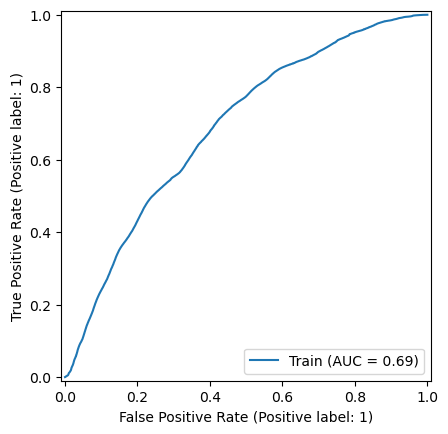

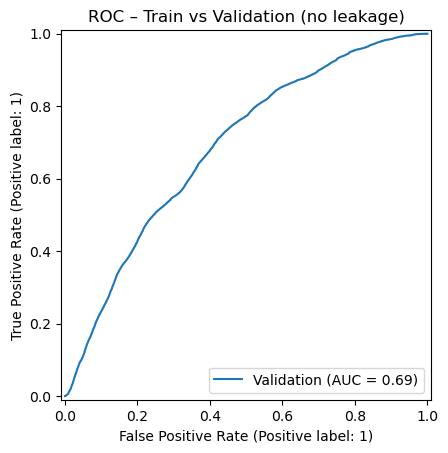

In [10]:
# AUC (threshold-free)
train_pred = pipe.predict_proba(X_train)[:, 1]
val_pred   = pipe.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
val_auc   = roc_auc_score(y_val, val_pred)

print(f"Train AUC: {train_auc:.4f}")
print(f"Val   AUC: {val_auc:.4f}")

# ROC curves
fig = plt.figure(figsize=(5,4))
RocCurveDisplay.from_predictions(y_train, train_pred, name="Train")
RocCurveDisplay.from_predictions(y_val,   val_pred,   name="Validation")
plt.title("ROC – Train vs Validation (no leakage)")
plt.show()


In [11]:
# Time-based split: Train on hist, validate on target.
# Build features for candidates in target ONLY (done above).
# For a fair time-based val, you can also build a train set of candidates from the week BEFORE cutoff.

# Example: train candidates from the penultimate week
penult_start = cutoff_date - pd.Timedelta(days=7)
penult_hist  = transactions[(transactions[DT_COL] >= penult_start) & (transactions[DT_COL] < cutoff_date)].copy()

train_pos = penult_hist[[ID_CUSTOMER, ID_ITEM]].drop_duplicates().assign(label=1)

rng = check_random_state(RANDOM_STATE)
unique_customers_tr = train_pos[ID_CUSTOMER].unique()
unique_items_all = transactions[ID_ITEM].unique()
pos_map_tr = train_pos.groupby(ID_CUSTOMER)[ID_ITEM].apply(set).to_dict()

neg_rows_tr = []
negatives_per_pos = 1
for cust in unique_customers_tr:
    pos_items = pos_map_tr.get(cust, set())
    n_pos = len(pos_items)
    n_neg = n_pos * negatives_per_pos
    pool = np.setdiff1d(unique_items_all, np.array(list(pos_items)))
    if len(pool) == 0 or n_neg == 0:
        continue
    sampled = rng.choice(pool, size=min(n_neg, len(pool)), replace=False)
    neg_rows_tr.extend([(cust, it, 0) for it in sampled])
train_neg = pd.DataFrame(neg_rows_tr, columns=[ID_CUSTOMER, ID_ITEM, "label"])

train_pairs_tb = pd.concat([train_pos, train_neg], ignore_index=True)

# Enrich train pairs with SAME past-only features (already computed from `hist`!)
train_df = (
    train_pairs_tb
    .merge(user_avg_price, on=ID_CUSTOMER, how="left")
    .merge(item_avg_price, on=ID_ITEM, how="left")
    .merge(user_last_purchase[[ID_CUSTOMER, "recency_days"]], on=ID_CUSTOMER, how="left")
)

if CAT_COL is not None:
    train_df = train_df.merge(articles[[ID_ITEM, CAT_COL]], on=ID_ITEM, how="left")
    if user_category_history is not None:
        train_df["has_bought_category_before"] = train_df[[ID_CUSTOMER, CAT_COL]].merge(
            user_category_history.assign(has_bought_category_before=1),
            on=[ID_CUSTOMER, CAT_COL], how="left"
        )["has_bought_category_before"].fillna(0).astype("int8")
    else:
        train_df["has_bought_category_before"] = 0

for col in ["user_avg_price", "item_avg_price", "recency_days"]:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna(train_df[col].median())

X_train = train_df[features].copy()
y_train = train_df["label"].values

# Keep val_df from earlier (target week)
X_val = training_data[features].copy()
y_val = training_data["label"].values

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])
pipe.fit(X_train, y_train)

train_pred = pipe.predict_proba(X_train)[:, 1]
val_pred   = pipe.predict_proba(X_val)[:, 1]
print(f"Train AUC (time-based train set): {roc_auc_score(y_train, train_pred):.4f}")
print(f"Val   AUC (target week):          {roc_auc_score(y_val,   val_pred):.4f}")


Train AUC (time-based train set): 0.7855
Val   AUC (target week):          0.6325


=== Summary (threshold chosen on Validation by Youden's J) ===
[Train] ROC AUC: 0.7855 | PR AUC (AP): 0.7183
  @thr=0.6275 → TP:148826 FP:54460 TN:182692 FN:88326 | Precision:0.7321 Recall:0.6276 TPR:0.6276 FPR:0.2296
[Validation] ROC AUC: 0.6325 | PR AUC (AP): 0.6009
  @thr=0.6275 → TP:134040 FP:80408 TN:156214 FN:102582 | Precision:0.6250 Recall:0.5665 TPR:0.5665 FPR:0.3398


<Figure size 600x500 with 0 Axes>

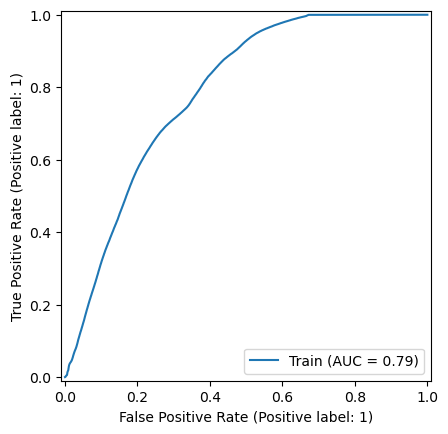

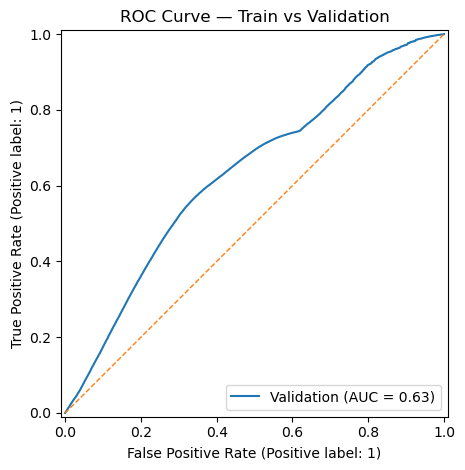

<Figure size 600x500 with 0 Axes>

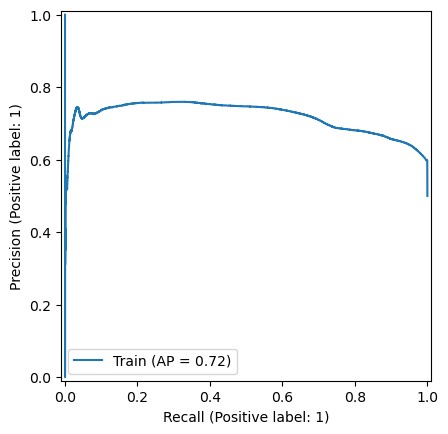

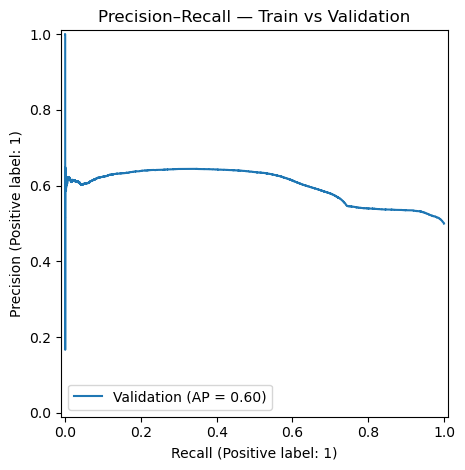


=== Validation Classification Report @ chosen threshold ===
              precision    recall  f1-score   support

           0     0.6036    0.6602    0.6306    236622
           1     0.6250    0.5665    0.5943    236622

    accuracy                         0.6133    473244
   macro avg     0.6143    0.6133    0.6125    473244
weighted avg     0.6143    0.6133    0.6125    473244



In [12]:
# ============================================
# FINAL CELL — METRICS + ROC & PR CURVES
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

def summarize_split(name, y_true, y_prob, threshold=None):
    auc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    print(f"[{name}] ROC AUC: {auc:.4f} | PR AUC (AP): {ap:.4f}")
    if threshold is not None:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tpr
        print(f"  @thr={threshold:.4f} → TP:{tp} FP:{fp} TN:{tn} FN:{fn} | Precision:{prec:.4f} Recall:{rec:.4f} TPR:{tpr:.4f} FPR:{fpr:.4f}")

# 1) Predict probabilities
train_prob = pipe.predict_proba(X_train)[:, 1]
val_prob   = pipe.predict_proba(X_val)[:, 1]

# 2) Choose a VALIDATION threshold via Youden's J (TPR - FPR)
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_prob)
youden_idx = np.argmax(tpr_v - fpr_v)
best_thr = thr_v[youden_idx]

# 3) Print summary metrics
print("=== Summary (threshold chosen on Validation by Youden's J) ===")
summarize_split("Train", y_train, train_prob, threshold=best_thr)
summarize_split("Validation", y_val, val_prob, threshold=best_thr)

# 4) ROC curve (Train vs Validation)
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_train, train_prob, name="Train")
RocCurveDisplay.from_predictions(y_val,   val_prob,   name="Validation")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.title("ROC Curve — Train vs Validation")
plt.tight_layout()
plt.show()

# 5) Precision–Recall curve (Train vs Validation)
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_train, train_prob, name="Train")
PrecisionRecallDisplay.from_predictions(y_val,   val_prob,   name="Validation")
plt.title("Precision–Recall — Train vs Validation")
plt.tight_layout()
plt.show()

# 6) (Optional) Detailed classification report on Validation @ best_thr
y_val_pred = (val_prob >= best_thr).astype(int)
print("\n=== Validation Classification Report @ chosen threshold ===")
print(classification_report(y_val, y_val_pred, digits=4))
